# SCF and Multipole Expansions

galpy supports two complementary basis-function-expansion techniques for representing the gravitational potential of arbitrary density distributions:

- **SCFPotential** uses the self-consistent field (SCF) method of [Hernquist & Ostriker (1992)](https://ui.adsabs.harvard.edu/abs/1992ApJ...386..375H), which expands a density in a biorthogonal basis set built from the Hernquist potential. This works well for smooth, roughly spheroidal systems.
- **MultipoleExpansionPotential** uses a spherical-harmonic (multipole) expansion where the radial functions are computed by direct integration. This is often more accurate than SCF for non-spherical systems, and it naturally supports time dependence.

For background on multipole expansions, see [Chapter 12.3.1 of Bovy (2026)](https://galaxiesbook.org/chapters/III-01.-Gravitation-in-Elliptical-Galaxies-and-Dark-Matter-Halos_3-Multipole-and-basis-function-expansions.html#Multipole-expansions). The SCF method is based on [Hernquist & Ostriker (1992)](http://adsabs.harvard.edu/abs/1992ApJ...386..375H).

Both approaches let you turn *any* density function into a potential that can be used for orbit integration, action-angle calculations, and all other galpy operations. This tutorial demonstrates how to use both, and also covers the disk-specific variants `DiskSCFPotential` and `DiskMultipoleExpansionPotential`.

In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)
import numpy
from matplotlib import pyplot as plt
from galpy import potential
from galpy.potential import (
    SCFPotential,
    MultipoleExpansionPotential,
    DiskSCFPotential,
    TriaxialNFWPotential,
    HernquistPotential,
    DoubleExponentialDiskPotential,
    scf_compute_coeffs_spherical,
)
from galpy.orbit import Orbit

## SCFPotential from a density

The `SCFPotential.from_density` class method builds an SCF expansion from any density function. As an example, we use a `TriaxialNFWPotential` with `c=1.4`, which stretches the density along the $z$-axis and makes the isodensity surfaces oblate (flattened in $R$). We use a large SCF scale length `a=50` and expansion orders `N=20, L=20`.

In [2]:
tri_nfw = TriaxialNFWPotential(normalize=1.0, c=1.4, a=1.0)

scf_tri = SCFPotential.from_density(tri_nfw, 20, L=20, a=50.0, symmetry="axisymmetry")

We can check how well the SCF expansion reproduces the true density by comparing along the $R = z$ line:

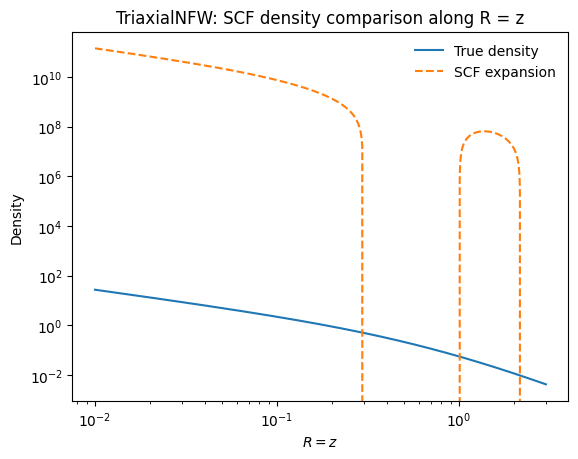

In [3]:
xs = numpy.linspace(0.01, 3.0, 1001)
plt.loglog(xs, [tri_nfw.dens(x, x) for x in xs], label="True density")
plt.loglog(xs, scf_tri.dens(xs, xs), "--", label="SCF expansion")
plt.xlabel(r"$R = z$")
plt.ylabel(r"Density")
plt.legend(frameon=False)
plt.title("TriaxialNFW: SCF density comparison along R = z");

The SCF expansion matches the true density very well over several orders of magnitude.

## MultipoleExpansionPotential from a density

`MultipoleExpansionPotential.from_density` provides an alternative expansion using spherical harmonics. We build one for the same oblate TriaxialNFW density.

<div class="alert alert-info">

**Tip:** Because `MultipoleExpansionPotential` supports time-dependent densities, it checks whether the density function accepts a `t` parameter. If you pass a method like `tri_nfw.dens` (which has a `t` keyword), it will be interpreted as time-dependent and require a `tgrid`. To avoid this, pass the potential object directly (as below) or wrap the density in a `lambda` that strips the `t` parameter: `lambda R, z, phi: pot.dens(R, z, phi)`.

</div>

In [4]:
mep_tri = MultipoleExpansionPotential.from_density(
    tri_nfw, L=20, symmetry="axisymmetry"
)

Now we can compare all three densities (true, SCF, and multipole) in a single plot:

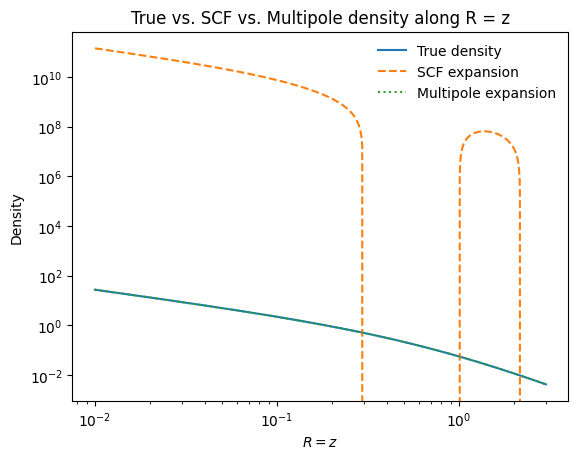

In [5]:
xs = numpy.linspace(0.01, 3.0, 1001)
plt.loglog(xs, [tri_nfw.dens(x, x) for x in xs], label="True density")
plt.loglog(xs, scf_tri.dens(xs, xs), "--", label="SCF expansion")
plt.loglog(xs, mep_tri.dens(xs, xs), ":", label="Multipole expansion")
plt.xlabel(r"$R = z$")
plt.ylabel(r"Density")
plt.legend(frameon=False)
plt.title("True vs. SCF vs. Multipole density along R = z");

Both expansion methods faithfully reproduce the gravitational field and can be used for orbit integration, action-angle calculations, and all other galpy operations.

## Computing SCF coefficients manually

Instead of using `from_density`, you can compute the SCF expansion coefficients yourself and pass them directly to `SCFPotential`. This is useful when you want to inspect the coefficients or store them for later use.

The Hernquist profile is the lowest-order SCF basis function, so only the zeroth-order coefficient should be non-zero in the following example:

In [6]:
hp = HernquistPotential(amp=1.0, a=2.0)
Acos, Asin = scf_compute_coeffs_spherical(hp.dens, 10, a=2.0)
print("Acos coefficients:")
print(Acos)
print(
    "\nAs expected, only Acos[0,0,0] = 1.0 is non-zero; all others are at machine precision."
)

Acos coefficients:
[[[ 1.00000000e+00]]

 [[ 8.65722568e-18]]

 [[-1.13278379e-16]]

 [[-2.93522527e-18]]

 [[-3.04900866e-17]]

 [[-8.03257697e-20]]

 [[-1.36005913e-17]]

 [[ 1.30909657e-18]]

 [[-5.31153122e-18]]

 [[-6.69176217e-19]]]

As expected, only Acos[0,0,0] = 1.0 is non-zero; all others are at machine precision.


To build an `SCFPotential` from these coefficients:

```python
sp_hernquist = SCFPotential(Acos=Acos, Asin=Asin, a=2.)
```

## DiskSCFPotential

For disk-like density distributions, the standard SCF expansion converges slowly because spherical basis functions are a poor match for thin, flat structures. `DiskSCFPotential` uses a trick to greatly improve convergence for disky systems.

The disk density is approximated as $\rho_{\mathrm{disk}}(R,\phi,z) \approx \sum_i \Sigma_i(R)\,h_i(z)$, with $h_i(z) = \mathrm{d}^2 H(z) / \mathrm{d} z^2$, and the potential is written as

$$\Phi(R,\phi,z) = \Phi_{\mathrm{ME}}(R,\phi,z) + 4\pi G\sum_i \Sigma_i(r)\,H_i(z)$$

where $r^2 = R^2+z^2$ is the spherical radius. The density giving rise to $\Phi_{\mathrm{ME}}$ is not strongly confined to a plane and can be obtained using the multipole or SCF methods. This trick is due to [Kuijken & Dubinski (1995)](http://adsabs.harvard.edu/abs/1995MNRAS.277.1341K).

As an example, we represent a `DoubleExponentialDiskPotential` with $h_R = 1/3$ and $h_z = 1/27$:

In [7]:
dp = DoubleExponentialDiskPotential(amp=13.5, hr=1.0 / 3.0, hz=1.0 / 27.0)

dscfp = DiskSCFPotential(
    dens=lambda R, z: dp.dens(R, z),
    Sigma={"type": "exp", "h": 1.0 / 3.0, "amp": 1.0},
    hz={"type": "exp", "h": 1.0 / 27.0},
    a=1.0,
    N=10,
    L=10,
)

Compare the density along the $R = 10z$ line:

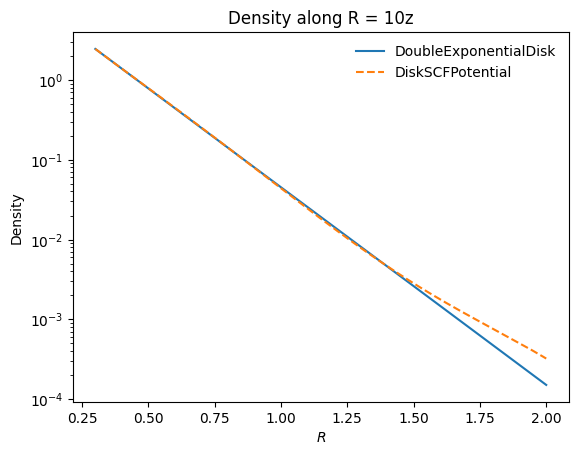

In [8]:
xs = numpy.linspace(0.3, 2.0, 1001)
plt.semilogy(xs, dp.dens(xs, xs / 10.0), label="DoubleExponentialDisk")
plt.semilogy(xs, dscfp.dens(xs, xs / 10.0), "--", label="DiskSCFPotential")
plt.xlabel(r"$R$")
plt.ylabel(r"Density")
plt.legend(frameon=False)
plt.title("Density along R = 10z");

The `DiskSCFPotential` reproduces the disk density very well. Orbit integration in `DiskSCFPotential` is also much faster than in `DoubleExponentialDiskPotential`, because the latter requires expensive numerical integrals at every force evaluation whereas `DiskSCFPotential` evaluates analytic basis functions:

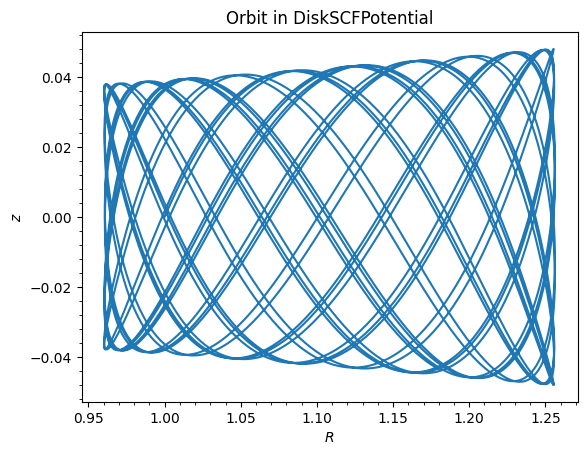

In [9]:
ts = numpy.linspace(0.0, 100.0, 10001)
ic_disk = [1.0, 0.1, 0.9, 0.0, 0.1, 0.0]

o_dscf = Orbit(ic_disk)
o_dscf.integrate(ts, dscfp)
o_dscf.plot()
plt.title("Orbit in DiskSCFPotential");

The orbits agree closely, but `DiskSCFPotential` is dramatically faster for orbit integration.

## DiskMultipoleExpansionPotential

galpy also provides `DiskMultipoleExpansionPotential`, which applies the same Kuijken & Dubinski disk-subtraction technique but uses a `MultipoleExpansionPotential` (instead of SCF) to solve the residual Poisson equation. Usage is analogous to `DiskSCFPotential` and can be more accurate for some density profiles.

## Time-dependent MultipoleExpansionPotential

The `MultipoleExpansionPotential` supports time-dependent densities. If you pass a density function that accepts a `t` keyword argument together with a `tgrid` array, galpy precomputes the expansion at each time step and interpolates. This is most useful for modeling potentials with complex time dependence, e.g., a time-dependent shape. In the following, we use a rotating bar as a simple example, but note that adding simple rotation is most easily accomplished using existing (or new) [wrappers](wrappers.ipynb).

As an example, we build a Hernquist-like density with a $\cos(2\phi)$ bar perturbation rotating at pattern speed $\Omega_p = 1.5$:

In [10]:
OmegaP = 1.5


def rotating_bar_dens(R, z, phi=0.0, t=0.0):
    phi_bar = phi - OmegaP * t
    r2 = R**2 + z**2
    rho0 = 1.0 / (r2**0.5 * (1.0 + r2**0.5) ** 3)
    return rho0 * (1.0 + 0.3 * numpy.cos(2.0 * phi_bar))


mep_td = MultipoleExpansionPotential.from_density(
    rotating_bar_dens,
    L=4,
    rgrid=numpy.geomspace(0.01, 20.0, 101),
    symmetry=None,
    tgrid=numpy.linspace(0.0, 4.0 * numpy.pi / OmegaP, 51),
)

We can visualize how the potential varies with azimuth at different times, confirming that the bar pattern rotates:

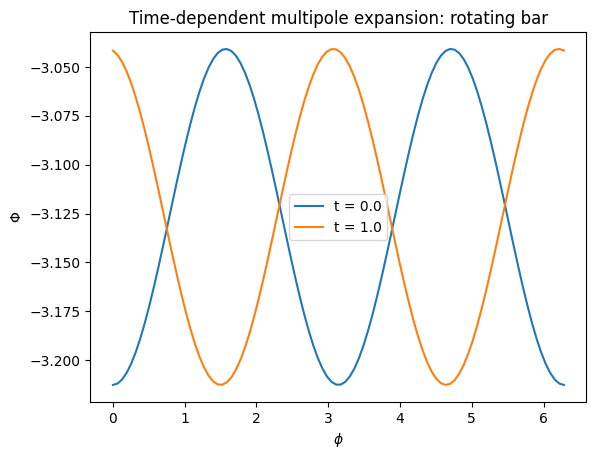

In [11]:
phis = numpy.linspace(0.0, 2.0 * numpy.pi, 100)
for t in [0.0, 1.0]:
    vals = [mep_td(1.0, 0.0, phi=phi, t=t) for phi in phis]
    plt.plot(phis, vals, label=f"t = {t:.1f}")
plt.xlabel(r"$\phi$")
plt.ylabel(r"$\Phi$")
plt.legend()
plt.title("Time-dependent multipole expansion: rotating bar");

The phase shift between the two curves shows the bar rotating at the specified pattern speed. This time-dependent multipole expansion can be used for orbit integration in the same way as any other galpy potential.